In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [2]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from healpix_analyse.make_rectangle import make_healpix_rectangle_from_lonlat
from healpix_analyse.resample import resample_to_latlon_grid
from healpix_analyse.ps import ps

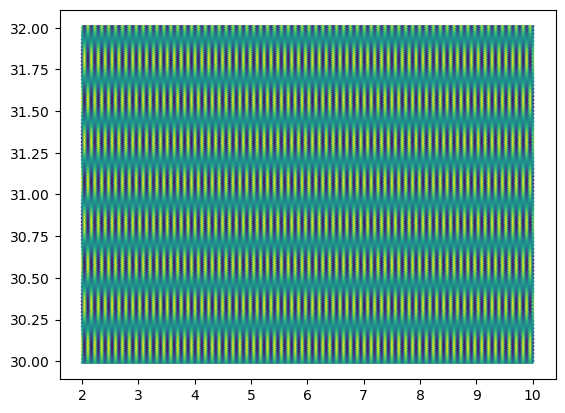

In [3]:
level = 12
ellipsoid = 'WGS84'

# Coverage box
lon_min, lon_max = 2.0, 10.0
lat_min, lat_max = 30.0, 32.0

cell_ids_2D_array = make_healpix_rectangle_from_lonlat(bbox=(lon_min, lat_min, lon_max, lat_max), 
                                                       level=level, 
                                                       ellipsoid=ellipsoid)

lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids_2D_array.flatten(), level, ellipsoid=ellipsoid)

def mock_data_function(lon, lat):
    definition = 20
    return np.cos(1024*(lon/definition + .1)) * np.sin(256*(lat/definition+.06)) + 0.5

data = mock_data_function(lon, lat)

plt.scatter(lon, lat, c=data, s=1)

In [4]:
cell_ids_2D_array

array([[50503771, 50503772, 50503773, ..., 50504133, 50504134, 50504135],
       [50487387, 50487388, 50487389, ..., 50487749, 50487750, 50487751],
       [50471003, 50471004, 50471005, ..., 50471365, 50471366, 50471367],
       ...,
       [47505499, 47505500, 47505501, ..., 47505861, 47505862, 47505863],
       [47489115, 47489116, 47489117, ..., 47489477, 47489478, 47489479],
       [47472731, 47472732, 47472733, ..., 47473093, 47473094, 47473095]],
      shape=(186, 365), dtype=uint64)

In [5]:
# reshape lat, lon, data as 2D array like cell_ids_2D_array
lat = lat.reshape(cell_ids_2D_array.shape)
lon = lon.reshape(cell_ids_2D_array.shape)
data = data.reshape(cell_ids_2D_array.shape)

In [6]:
data_resampled = resample_to_latlon_grid(lat, lon, data, method='cubic')

In [7]:
lon_grid, lat_grid = np.meshgrid(np.linspace(lon.min(), lon.max(), data.shape[1]),
                                 np.linspace(lat.min(), lat.max(), data.shape[0]))

data_truth = mock_data_function(lon_grid, lat_grid)

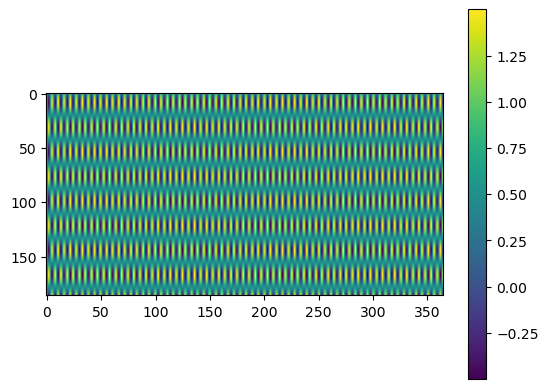

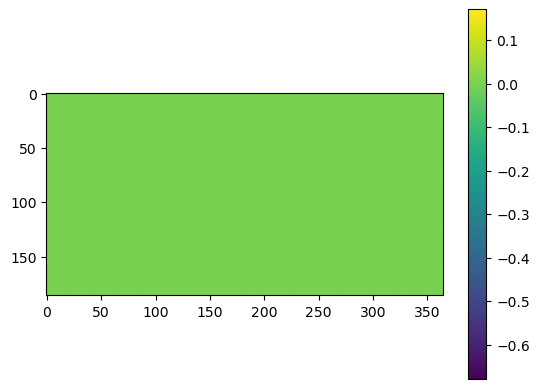

In [8]:
plt.imshow(data_resampled)
plt.colorbar()
plt.show()

plt.imshow(data_resampled - data_truth)
plt.colorbar()
plt.show()

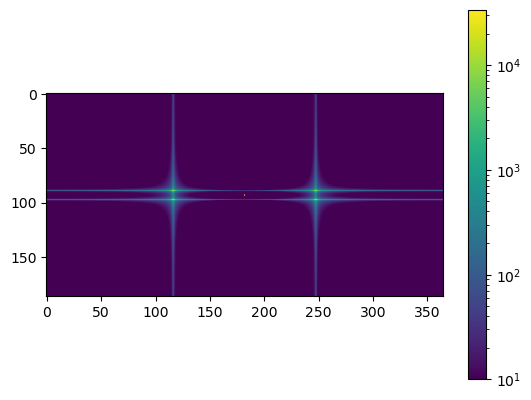

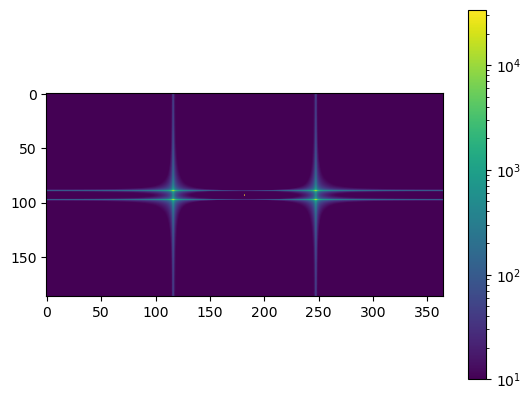

In [9]:
plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(data_truth))), norm='log', vmin=1e1)
plt.colorbar()
plt.show()

plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(data_resampled))), norm='log', vmin=1e1)
plt.colorbar()
plt.show()

In [10]:
nu_truth, cl_truth = ps(data_truth)
nu, cl = ps(data_resampled)
nu_cross, cl_cross = ps(data=data_resampled, data_cross=data_truth)

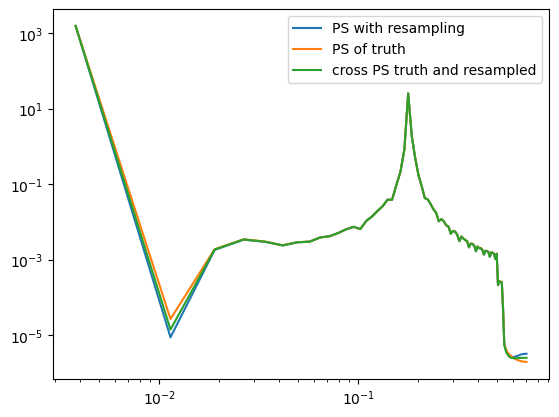

In [11]:
plt.plot(nu, cl, label='PS with resampling')
plt.plot(nu_truth, cl_truth, label='PS of truth')
plt.plot(nu_cross, cl_cross, label='cross PS truth and resampled')
plt.yscale('log')
plt.xscale('log')
plt.legend()